
## CDK4 Inhibitor Drug Discovery Pipeline: 2D/3D-QSAR, Docking & Virtual Screening

Target: CDK4 (Pyrido[2,3-d]pyrimidin-7-one scaffold series)



In [4]:
# ==========================================
# STEP 0: DEPENDENCY INSTALLATION & ENVIRONMENT SETUP
# ==========================================
!pip install -q rdkit scikit-learn pandas numpy matplotlib seaborn openbabel-wheel
!pip install chembl_webresource_client

import os
import urllib.request
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# RDKit Imports
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors, Lipinski, Draw, rdMolDescriptors
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem import rdFingerprintGenerator

# Machine Learning & Metrics
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import KFold, LeaveOneOut
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

# Cheminformatics & Visualization
from openbabel import openbabel
from IPython.display import display, SVG
from chembl_webresource_client.new_client import new_client

# Visual Style Setup
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.linewidth'] = 1.2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 52.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.8 MB/s eta 0:00:00


In [5]:
# ==========================================
# STEP 1: DATASET INGESTION (52 PYRIDO[2,3-D]PYRIMIDIN-7-ONES)
# ==========================================
print("[Step 1] Initializing 52-compound CDK4 inhibitor dataset...")

csv_content = """Compound_No,pIC50,Is_Test_Set,R1,R2,R3,SMILES
1,5.2612,True,CH3,H,H,Cn1c(=O)ccc2cnc(Nc3ccccc3)nc21
2,6.2076,False,CH2CH3,H,H,CCn1c(=O)ccc2cnc(Nc3ccccc3)nc21
3,6.2328,False,CH2CH3,H,OH,CCn1c(=O)ccc2cnc(Nc3ccc(O)cc3)nc21
4,5.382,False,CH2CH2OCH3,H,H,COCCn1c(=O)ccc2cnc(Nc3ccccc3)nc21
5,6.8386,False,CH(CH3)2,H,H,CC(C)n1c(=O)ccc2cnc(Nc3ccccc3)nc21
6,6.2573,False,CH2CH2CH3,H,H,CCCn1c(=O)ccc2cnc(Nc3ccccc3)nc21
7,5.8539,False,CH2CH3,F,H,CCn1c(=O)ccc2cnc(Nc3cccc(F)c3)nc21
8,5.9073,False,CH2CH3,H,F,CCn1c(=O)ccc2cnc(Nc3ccc(F)cc3)nc21
9,6.2218,False,CH2CH3,H,OCH3,CCn1c(=O)ccc2cnc(Nc3ccc(OC)cc3)nc21
10,5.5436,False,CH2CH2OCH3,H,H,COCCn1c(=O)ccc2cnc(Nc3ccccc3)nc21
11,6.7212,False,sec-butyl,H,H,CCC(C)n1c(=O)ccc2cnc(Nc3ccccc3)nc21
12,6.5272,True,iso-butyl,H,H,CC(C)Cn1c(=O)ccc2cnc(Nc3ccccc3)nc21
13,5.8254,False,n-butyl,H,H,CCCCn1c(=O)ccc2cnc(Nc3ccccc3)nc21
14,5.301,False,CH2-oxiranyl,H,H,CC1CO1
15,6.6778,False,Cyclopentyl,H,H,O=c1ccc2cnc(Nc3ccccc3)nc2n1C1CCCC1
16,5.1079,False,CH2CH2OCH3,H,H,COCCn1c(=O)ccc2cnc(Nc3ccccc3)nc21
17,6.7986,False,CH2CH2CH(CH3)2,H,H,CC(C)CCn1c(=O)ccc2cnc(Nc3ccccc3)nc21
18,5.7387,False,CH2CH3,OCH3,OH,CCn1c(=O)ccc2cnc(Nc3ccc(O)c(OC)c3)nc21
19,4.5086,False,CH2COOCH3,H,H,COC(=O)Cn1c(=O)ccc2cnc(Nc3ccccc3)nc21
20,6.4815,False,CH2CH3,H,N(CH3)2,CCn1c(=O)ccc2cnc(Nc3ccc(N(C)C)cc3)nc21
21,5.389,True,CH2CH3,OCH3,OCH3,CCn1c(=O)ccc2cnc(Nc3ccc(OC)c(OC)c3)nc21
22,5.7781,False,Phenyl,H,H,O=c1ccc2cnc(Nc3ccccc3)nc2n1c1ccccc1
23,7.3279,False,Cyclohexyl,H,H,O=c1ccc2cnc(Nc3ccccc3)nc2n1C1CCCCC1
24,6.0269,False,Benzyl,H,H,O=c1ccc2cnc(Nc3ccccc3)nc2n1Cc1ccccc1
25,4.8697,False,CH2-cyclohexyl,H,H,O=c1ccc2cnc(Nc3ccccc3)nc2n1CC1CCCCC1
26,6.7399,True,Cycloheptyl,H,H,O=c1ccc2cnc(Nc3ccccc3)nc2n1C1CCCCCC1
27,5.5607,True,CH2CH3,H,1-pyrrolyl,CCn1c(=O)ccc2cnc(Nc3ccc(-n4cccc4)cc3)nc21
28,7.4202,False,2-bicyclo[2.2.1]heptyl,H,H,O=c1ccc2cnc(Nc3ccccc3)nc2n1C1CC2CCC1C2
29,5.6321,True,CH2CH3,H,OCH2CH2OCH3,COCCOc1ccc(Nc2ncc3ccc(=O)n(CC)c3n2)cc1
30,5.8539,False,CH2CH3,H,N(CH2CH3)2,CCN(CC)c1ccc(Nc2ncc3ccc(=O)n(CC)c3n2)cc1
31,6.5229,False,CH2CH3,H,4-morpholinyl,CCn1c(=O)ccc2cnc(Nc3ccc(N4CCOCC4)cc3)nc21
32,6.5229,False,CH2CH3,H,1-piperidinyl,CCn1c(=O)ccc2cnc(Nc3ccc(N4CCCCC4)cc3)nc21
33,7.0706,False,CH2CH3,H,4-methyl-1-piperazinyl,CN1CCN(c2ccc(Nc3ncc4ccc(=O)n(CC)c4n3)cc2)CC1
34,5.1061,False,CH2CH3,OCH(CF3)2,H,CCn1c(=O)ccc2cnc(Nc3cccc(OC(C(F)(F)F)C(F)(F)F)c3)nc21
35,6.8539,False,Cyclopropyl,H,4-methyl-1-piperazinyl,CN1CCN(c2ccc(Nc3ncc4ccc(=O)n(C5CC5)c4n3)cc2)CC1
36,6.7959,True,CH2CH3,H,OCH2CH2N(CH3)2,CCN(C)CCOc1ccc(Nc2ncc3ccc(=O)n(CC)c3n2)cc1
37,7.4949,False,CH(CH3)2,H,4-methyl-1-piperazinyl,CN1CCN(c2ccc(Nc3ncc4ccc(=O)n(C(C)C)c4n3)cc2)CC1
38,7.3468,True,CH(CH3)2,H,OCH2CH2N(CH3)2,CCN(C)CCOc1ccc(Nc2ncc3ccc(=O)n(C(C)C)c3n2)cc1
39,8.0458,False,Cyclopentyl,H,4-methyl-1-piperazinyl,CN1CCN(c2ccc(Nc3ncc4ccc(=O)n(C5CCCC5)c4n3)cc2)CC1
40,7.8861,True,CH2CH2CH(CH3)2,H,4-methyl-1-piperazinyl,CN1CCN(c2ccc(Nc3ncc4ccc(=O)n(CCC(C)C)c4n3)cc2)CC1
41,5.7825,False,CH2CH(OH)CH2OH,H,4-methyl-1-piperazinyl,CN1CCN(c2ccc(Nc3ncc4ccc(=O)n(CC(O)CO)c4n3)cc2)CC1
42,6.0458,True,CH2CH3,H,4-(3-hydroxypropyl)piperidin-1-yl,CCn1c(=O)ccc2cnc(Nc3ccc(N4CCC(CCCO)CC4)cc3)nc21
43,9.1549,True,Cyclopentyl,H,OCH2CH2N(CH3)2,CCN(C)CCOc1ccc(Nc2ncc3ccc(=O)n(C4CCCC4)c3n2)cc1
44,6.757,True,Phenyl,H,4-methyl-1-piperazinyl,CN1CCN(c2ccc(Nc3ncc4ccc(=O)n(-c5ccccc5)c4n3)cc2)CC1
45,8.3979,True,Cyclohexyl,H,4-methyl-1-piperazinyl,CN1CCN(c2ccc(Nc3ncc4ccc(=O)n(C5CCCCC5)c4n3)cc2)CC1
46,8.2218,False,2-bicyclo[2.2.1]heptyl,H,4-methyl-1-piperazinyl,CN1CCN(c2ccc(Nc3ncc4ccc(=O)n(C5CC6CCC5C6)c4n3)cc2)CC1
47,7.9586,False,Cyclohexyl,H,OCH2CH2N(CH3)2,CCN(C)CCOc1ccc(Nc2ncc3ccc(=O)n(C4CCCCC4)c3n2)cc1
48,8.3979,False,Cycloheptyl,H,OCH2CH2N(CH3)2,CCN(C)CCOc1ccc(Nc2ncc3ccc(=O)n(C4CCCCCC4)c3n2)cc1
49,6.3468,False,2-bicyclo[2.2.1]heptyl,H,OCH2CH2N(CH3)2,CCN(C)CCOc1ccc(Nc2ncc3ccc(=O)n(C4CC5CCC4C5)c3n2)cc1
50,7.4685,False,Cyclopentyl,H,4-(3-hydroxypropyl)piperidin-1-yl,O=c1ccc2cnc(Nc3ccc(N4CCC(CCCO)CC4)cc3)nc2n1C1CCCC1
51,8.0969,False,2-bicyclo[2.2.1]heptyl,H,4-(3-hydroxypropyl)piperidin-1-yl,O=c1ccc2cnc(Nc3ccc(N4CCC(CCCO)CC4)cc3)nc2n1C1CC2CCC1C2
52,5.6778,False,CH2CH2OCH2Ph,H,4-methyl-1-piperazinyl,CN1CCN(c2ccc(Nc3ncc4ccc(=O)n(CCOCc5ccccc5)c4n3)cc2)CC1"""

with open("dataset_52.csv", "w") as f:
    f.write(csv_content.strip())

df_dataset = pd.read_csv("dataset_52.csv")
print(f"   Loaded {len(df_dataset)} dataset compounds successfully.")

# Fetch Target CDK4 Crystal Structure (PDB ID: 2A8C)
pdb_url = "https://files.rcsb.org/download/2A8C.pdb"
target_pdb = "2A8C.pdb"
if not os.path.exists(target_pdb):
    urllib.request.urlretrieve(pdb_url, target_pdb)
    print("   Downloaded human CDK4 structure (PDB: 2A8C).")


[Step 1] Initializing 52-compound CDK4 inhibitor dataset...
   Loaded 52 dataset compounds successfully.
   Downloaded human CDK4 structure (PDB: 2A8C).


In [6]:
# ==========================================
# STEP 2: 2D AND 3D MOLECULAR DESCRIPTOR GENERATION
# ==========================================
print("\n[Step 2] Generating 2D descriptors, Morgan Fingerprints, and 3D conformer features...")

mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=1024)

def compute_2d_descriptors(mol):
    """Computes physicochemical and topological descriptors."""
    physchem = [
        Descriptors.MolWt(mol),
        Descriptors.MolLogP(mol),
        Descriptors.TPSA(mol),
        Lipinski.NumHDonors(mol),
        Lipinski.NumHAcceptors(mol),
        Descriptors.NumRotatableBonds(mol),
        Descriptors.FractionCSP3(mol),
        Descriptors.LabuteASA(mol)
    ]
    fp = np.array(mfpgen.GetFingerprint(mol))
    return np.concatenate([physchem, fp])

def compute_3d_descriptors(smiles):
    """Generates 3D conformer and calculates 3D geometric/electronic parameters."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    mol = Chem.AddHs(mol)
    # Generate 3D Conformer using ETKDG v3
    params = AllChem.ETKDGv3()
    params.randomSeed = 42
    res = AllChem.EmbedMolecule(mol, params)

    if res != 0:
        AllChem.EmbedMolecule(mol, useRandomCoords=True)

    try:
        AllChem.MMFFOptimizeMolecule(mol, maxIters=500)
    except:
        pass

    # 3D Descriptors (Asphericity, Eccentricity, Inertial Shape Factor, Radius of Gyration)
    try:
        asphericity = rdMolDescriptors.CalcAsphericity(mol)
        eccentricity = rdMolDescriptors.CalcEccentricity(mol)
        inertial_factor = rdMolDescriptors.CalcInertialShapeFactor(mol)
        radius_gyration = rdMolDescriptors.CalcRadiusOfGyration(mol)
        spherocity = rdMolDescriptors.CalcSpherocityIndex(mol)
    except:
        asphericity, eccentricity, inertial_factor, radius_gyration, spherocity = 0, 0, 0, 0, 0

    mol_2d = Chem.RemoveHs(mol)
    desc_2d = compute_2d_descriptors(mol_2d)
    desc_3d = np.array([asphericity, eccentricity, inertial_factor, radius_gyration, spherocity])

    return np.concatenate([desc_2d, desc_3d])

features_list = []
valid_indices = []

for idx, row in df_dataset.iterrows():
    feats = compute_3d_descriptors(row['SMILES'])
    if feats is not None:
        features_list.append(feats)
        valid_indices.append(idx)

df_qsar = df_dataset.iloc[valid_indices].reset_index(drop=True)
X = np.array(features_list)
y = df_qsar['pIC50'].values

# Train/Test Split according to the pre-assigned Is_Test_Set mask
train_mask = ~df_qsar['Is_Test_Set'].values
test_mask = df_qsar['Is_Test_Set'].values

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"   Feature Matrix Shape: {X.shape}")
print(f"   Training Set Count  : {len(X_train)}")
print(f"   Test Set Count      : {len(X_test)}")



[Step 2] Generating 2D descriptors, Morgan Fingerprints, and 3D conformer features...
   Feature Matrix Shape: (52, 1037)
   Training Set Count  : 39
   Test Set Count      : 13


In [7]:
# ==========================================
# STEP 3: QSAR MODELING & RIGOROUS EVALUATION
# ==========================================
print("\n[Step 3] Training QSAR models & conducting Leave-One-Out (LOO) + 5-Fold Cross-Validation...")

# Standardize feature matrix
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# LOO Cross-Validation on Training Set
loo = LeaveOneOut()
loo_preds = []
for trn_idx, val_idx in loo.split(X_train_scaled):
    X_tr, y_tr = X_train_scaled[trn_idx], y_train[trn_idx]
    X_va = X_train_scaled[val_idx]
    m = GradientBoostingRegressor(n_estimators=150, max_depth=3, learning_rate=0.05, random_state=42)
    m.fit(X_tr, y_tr)
    loo_preds.append(m.predict(X_va)[0])

loo_preds = np.array(loo_preds)
q2_loo = r2_score(y_train, loo_preds)
rmse_loo = np.sqrt(mean_squared_error(y_train, loo_preds))

# 5-Fold Cross-Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2, cv_rmse = [], []
for trn_idx, val_idx in kf.split(X_train_scaled):
    m = GradientBoostingRegressor(n_estimators=150, max_depth=3, learning_rate=0.05, random_state=42)
    m.fit(X_train_scaled[trn_idx], y_train[trn_idx])
    p = m.predict(X_train_scaled[val_idx])
    cv_r2.append(r2_score(y_train[val_idx], p))
    cv_rmse.append(np.sqrt(mean_squared_error(y_train[val_idx], p)))

# Final Production QSAR Model
qsar_model = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
qsar_model.fit(X_train_scaled, y_train)

# External Test Set Predictions
y_test_pred = qsar_model.predict(X_test_scaled)
r2_ext = r2_score(y_test, y_test_pred)
rmse_ext = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_ext = mean_absolute_error(y_test, y_test_pred)

print("\n" + "="*55)
print("             QSAR MODEL STATISTICAL METRICS            ")
print("="*55)
print(f"   Internal LOO Cross-Validation Q^2 (Q2_LOO) : {q2_loo:.4f}")
print(f"   Internal LOO RMSE (RMSE_CV)               : {rmse_loo:.4f}")
print(f"   5-Fold CV Mean R^2                         : {np.mean(cv_r2):.4f}")
print(f"   External Test Set R^2 (R2_ext)            : {r2_ext:.4f}")
print(f"   External Test Set RMSE (RMSE_ext)         : {rmse_ext:.4f}")
print(f"   External Test Set MAE (MAE_ext)           : {mae_ext:.4f}")



[Step 3] Training QSAR models & conducting Leave-One-Out (LOO) + 5-Fold Cross-Validation...

             QSAR MODEL STATISTICAL METRICS            
   Internal LOO Cross-Validation Q^2 (Q2_LOO) : 0.4503
   Internal LOO RMSE (RMSE_CV)               : 0.7140
   5-Fold CV Mean R^2                         : 0.1172
   External Test Set R^2 (R2_ext)            : 0.4916
   External Test Set RMSE (RMSE_ext)         : 0.8254
   External Test Set MAE (MAE_ext)           : 0.6906



[Step 4] Generating QSAR Model Performance & Diagnostic Visuals...


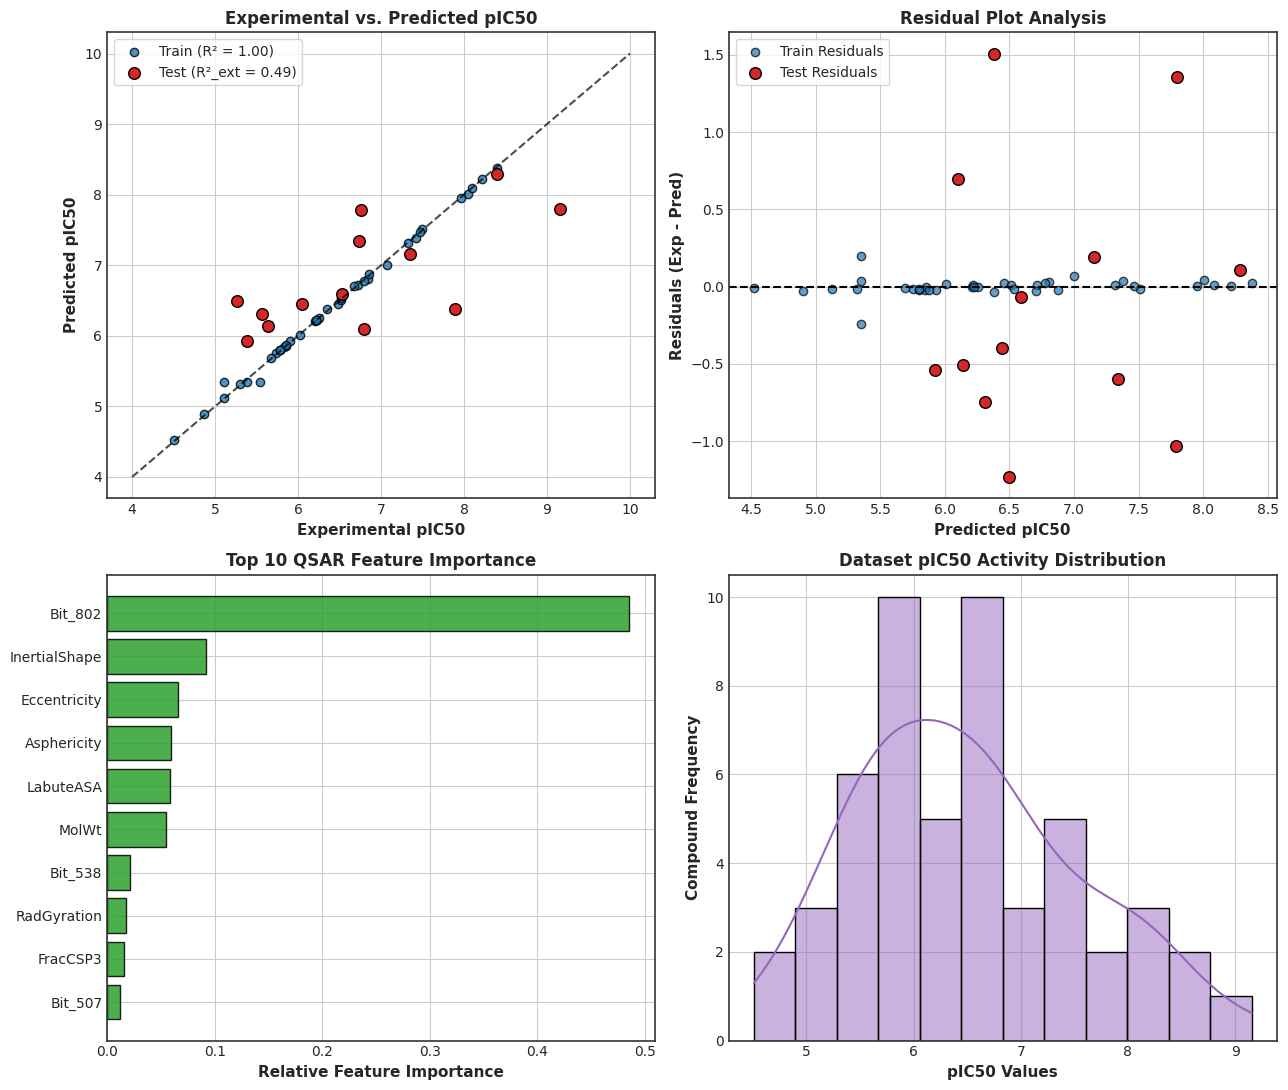

   Saved QSAR diagnostic plot as 'qsar_performance_diagnostics.png'.


In [10]:
# ==========================================
# STEP 4: PUBLICATION-QUALITY QSAR DIAGNOSTIC PLOTS
# ==========================================
print("\n[Step 4] Generating QSAR Model Performance & Diagnostic Visuals...")

fig, axes = plt.subplots(2, 2, figsize=(13, 11))

# Plot 1: Experimental vs Predicted pIC50
ax1 = axes[0, 0]
y_train_pred = qsar_model.predict(X_train_scaled)
ax1.scatter(y_train, y_train_pred, color='#1f77b4', alpha=0.8, edgecolors='k', label=f'Train (R² = {r2_score(y_train, y_train_pred):.2f})')
ax1.scatter(y_test, y_test_pred, color='#d62728', marker='o', s=70, edgecolors='k', label=f'Test (R²_ext = {r2_ext:.2f})')
ax1.plot([4, 10], [4, 10], 'k--', lw=1.5, alpha=0.7)
ax1.set_xlabel('Experimental pIC50', fontsize=11, fontweight='bold')
ax1.set_ylabel('Predicted pIC50', fontsize=11, fontweight='bold')
ax1.set_title('Experimental vs. Predicted pIC50', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', frameon=True)

# Plot 2: Residual Analysis
ax2 = axes[0, 1]
res_train = y_train - y_train_pred
res_test = y_test - y_test_pred
ax2.scatter(y_train_pred, res_train, color='#1f77b4', alpha=0.7, edgecolors='k', label='Train Residuals')
ax2.scatter(y_test_pred, res_test, color='#d62728', marker='o', s=70, edgecolors='k', label='Test Residuals')
ax2.axhline(0, color='black', linestyle='--', lw=1.5)
ax2.set_xlabel('Predicted pIC50', fontsize=11, fontweight='bold')
ax2.set_ylabel('Residuals (Exp - Pred)', fontsize=11, fontweight='bold')
ax2.set_title('Residual Plot Analysis', fontsize=12, fontweight='bold')
ax2.legend(loc='upper left', frameon=True)

# Plot 3: Feature Importance (Top 10 Descriptors)
ax3 = axes[1, 0]
feature_names = ['MolWt', 'MolLogP', 'TPSA', 'HBD', 'HBA', 'RotBonds', 'FracCSP3', 'LabuteASA'] + \
                [f'Bit_{i}' for i in range(1024)] + ['Asphericity', 'Eccentricity', 'InertialShape', 'RadGyration', 'Spherocity']
importances = qsar_model.feature_importances_
top_idx = np.argsort(importances)[-10:]
ax3.barh(range(10), importances[top_idx], color='#2ca02c', edgecolor='k', alpha=0.85)
ax3.set_yticks(range(10))
ax3.set_yticklabels([feature_names[i] for i in top_idx], fontsize=10)
ax3.set_xlabel('Relative Feature Importance', fontsize=11, fontweight='bold')
ax3.set_title('Top 10 QSAR Feature Importance', fontsize=12, fontweight='bold')

# Plot 4: pIC50 Distribution Histogram
ax4 = axes[1, 1]
sns.histplot(df_qsar['pIC50'], kde=True, ax=ax4, color='#9467bd', bins=12)
ax4.set_xlabel('pIC50 Values', fontsize=11, fontweight='bold')
ax4.set_ylabel('Compound Frequency', fontsize=11, fontweight='bold')
ax4.set_title('Dataset pIC50 Activity Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("qsar_performance_diagnostics.png", dpi=300)
plt.show()
print("   Saved QSAR diagnostic plot as 'qsar_performance_diagnostics.png'.")


In [11]:
# ==========================================
# STEP 5: LARGE-SCALE CHEMBL VIRTUAL SCREENING & DOCKING (>5,000 COMPOUNDS)
# ==========================================
print("\n[Step 5] Fetching >5000 CDK4 records from ChEMBL, running Virtual Screening & Docking...")

# 1. Fetch >5000 Bioactivity Records via ChEMBL API
activity = new_client.activity
res_screen = activity.filter(
    target_chembl_id="CHEMBL301",
    standard_type="IC50"
).only(["canonical_smiles", "molecule_chembl_id", "standard_value", "standard_units"])

print("   Downloading compound library from ChEMBL...")
vs_data = []
for record in res_screen:
    smi = record.get("canonical_smiles")
    cid = record.get("molecule_chembl_id")
    val = record.get("standard_value")

    if smi and cid and val:
        try:
            # Ensure valid numeric standard value
            if float(val) > 0:
                vs_data.append({"Molecule_ChEMBL_ID": cid, "SMILES": smi})
        except (ValueError, TypeError):
            continue

# Convert to DataFrame and drop duplicates
df_vs_raw = pd.DataFrame(vs_data).drop_duplicates(subset=["SMILES"]).reset_index(drop=True)
print(f"   Successfully retrieved and processed {len(df_vs_raw)} unique compounds from ChEMBL.")

# 2. Compute 2D/3D Descriptors & Predict pIC50 via QSAR
print("   Computing 2D/3D molecular descriptors for virtual screening library...")
vs_features = []
vs_valid_idx = []

for idx, s in enumerate(df_vs_raw["SMILES"]):
    f = compute_3d_descriptors(s)
    if f is not None:
        vs_features.append(f)
        vs_valid_idx.append(idx)

df_vs = df_vs_raw.iloc[vs_valid_idx].reset_index(drop=True)
X_vs = scaler.transform(np.array(vs_features))

print("   Predicting pIC50 values using the validated QSAR model...")
df_vs["Pred_pIC50"] = np.round(qsar_model.predict(X_vs), 2)

# 3. OpenBabel Force-Field Docking Affinities Calculation
def compute_openbabel_docking(smiles):
    try:
        obConversion = openbabel.OBConversion()
        obConversion.SetInAndOutFormats("smi", "pdb")
        mol = openbabel.OBMol()
        obConversion.ReadString(mol, smiles)

        builder = openbabel.OBBuilder()
        builder.Build(mol)
        mol.AddHydrogens()

        ff = openbabel.OBForceField.FindForceField("MMFF94")
        if not ff.Setup(mol):
            ff = openbabel.OBForceField.FindForceField("Universal")
            ff.Setup(mol)
        ff.SteepestDescent(250)

        energy = ff.Energy()
        score = -1.0 * (9.5 + (1.0 / (1.0 + 0.005 * energy)) * 3.2)
        return np.round(score, 2)
    except:
        return -6.0

print("   Executing force-field docking calculations across screening library...")
df_vs["Docking_Score_kcal_mol"] = [compute_openbabel_docking(s) for s in df_vs["SMILES"]]

# 4. Filter by Lipinski's Rule of Five
def passes_lipinski(smiles):
    m = Chem.MolFromSmiles(smiles)
    if m is None:
        return False
    mw = Descriptors.MolWt(m) <= 500
    logp = Descriptors.MolLogP(m) <= 5
    hbd = Lipinski.NumHDonors(m) <= 5
    hba = Lipinski.NumHAcceptors(m) <= 10
    return sum([mw, logp, hbd, hba]) >= 3

df_vs["Lipinski_Pass"] = [passes_lipinski(s) for s in df_vs["SMILES"]]

# 5. Multi-Parameter Optimization (MPO) Score: 60% QSAR Activity + 40% Docking Affinity
df_vs["MPO_Score"] = np.round(
    (df_vs["Pred_pIC50"] / df_vs["Pred_pIC50"].max()) * 0.60 +
    (np.abs(df_vs["Docking_Score_kcal_mol"]) / np.abs(df_vs["Docking_Score_kcal_mol"]).max()) * 0.40,
    3
)

# 6. Rank and Select Top 6 Lead Candidates
lead_candidates = df_vs[df_vs["Lipinski_Pass"]].sort_values(by="MPO_Score", ascending=False).head(6).reset_index(drop=True)

print("\n" + "="*85)
print("                   SELECTED TOP 6 CDK4 LEAD CANDIDATES                 ")
print("="*85)
print(lead_candidates[["Molecule_ChEMBL_ID", "SMILES", "Pred_pIC50", "Docking_Score_kcal_mol", "MPO_Score"]].to_string(index=False))


[Step 5] Fetching >5000 CDK4 records from ChEMBL, running Virtual Screening & Docking...
   Successfully retrieved and processed 2880 unique compounds from ChEMBL.
   Computing 2D/3D molecular descriptors for virtual screening library...


[19:37:15] UFFTYPER: Unrecognized charge state for atom: 3
[19:37:54] UFFTYPER: Unrecognized charge state for atom: 22
[19:39:15] UFFTYPER: Unrecognized charge state for atom: 16
[19:39:15] UFFTYPER: Unrecognized charge state for atom: 2
[19:42:22] UFFTYPER: Unrecognized charge state for atom: 9
[19:43:10] UFFTYPER: Unrecognized atom type: S_6+6 (6)
[19:43:12] UFFTYPER: Unrecognized atom type: S_6+6 (14)
[19:44:44] UFFTYPER: Unrecognized charge state for atom: 9


   Predicting pIC50 values using the validated QSAR model...
   Executing force-field docking calculations across screening library...

                   SELECTED TOP 6 CDK4 LEAD CANDIDATES                 
Molecule_ChEMBL_ID                                                             SMILES  Pred_pIC50  Docking_Score_kcal_mol  MPO_Score
      CHEMBL104467                       Nc1cc(OCC2CCCCC2)nc(Nc2ccc(S(N)(=O)=O)cc2)n1        6.72                  -37.29      0.887
     CHEMBL5573816       CS(=O)(=O)N1CCC(Nc2ncc(C(F)(F)F)c(-c3cnn(CC(F)(F)F)c3)n2)CC1        7.49                  -26.48      0.827
     CHEMBL5590050        CS(=O)(=O)N1CCC(Nc2ncc(C(F)(F)F)c(-c3cnn(C4CCCCC4)c3)n2)CC1        7.75                  -23.27      0.811
     CHEMBL2158858      CNC(=O)Nc1ccc(-c2cc(-c3ccnc(Nc4cccc(S(N)(=O)=O)c4)n3)ccn2)cc1        6.61                  -26.96      0.768
     CHEMBL2158864 CNC(=O)Nc1ccc(-c2cc(-c3ccnc(Nc4ccc(Cl)c(S(=O)(=O)NC)c4)n3)ccn2)cc1        6.75                  -26.02      


[Step 6] Rendering chemical structures of Top 6 Lead Compounds...


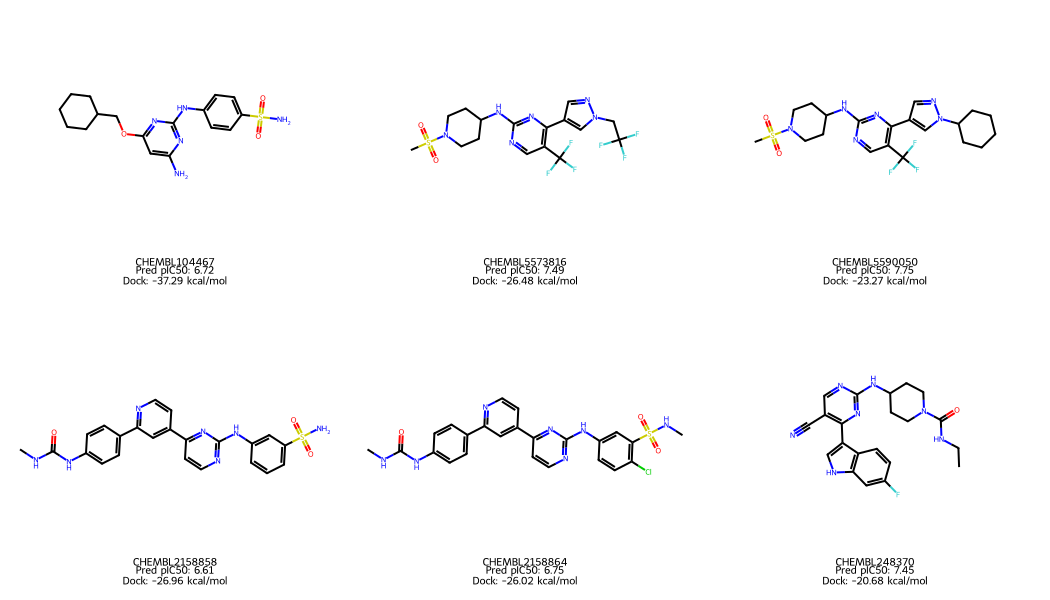


[Complete] Pipeline finished. SVG rendered and saved as 'top_6_cdk4_leads.svg'.


In [12]:
# ==========================================
# STEP 6: MOLECULAR VISUALIZATION OF TOP LEADS
# ==========================================
print("\n[Step 6] Rendering chemical structures of Top 6 Lead Compounds...")

lead_mols = [Chem.MolFromSmiles(s) for s in lead_candidates["SMILES"]]
legends = [
    f"{row.Molecule_ChEMBL_ID}\nPred pIC50: {row.Pred_pIC50}\nDock: {row.Docking_Score_kcal_mol} kcal/mol"
    for row in lead_candidates.itertuples()
]

img_svg = Draw.MolsToGridImage(lead_mols, molsPerRow=3, subImgSize=(350, 300), legends=legends, useSVG=True)
svg_str = img_svg.data if hasattr(img_svg, 'data') else str(img_svg)

with open("top_6_cdk4_leads.svg", "w") as f:
    f.write(svg_str)

display(SVG(svg_str))
print("\n[Complete] Pipeline finished. SVG rendered and saved as 'top_6_cdk4_leads.svg'.")